In [5]:
import os, json, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import SimpleITK as sitk
import yaml
from rich import print as rprint
from rich.table import Table
from rich.console import Console
from tqdm import tqdm

# project root
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

with open(ROOT / "config.yaml") as f:
    cfg = yaml.safe_load(f)

IMAGES_DIR = ROOT / cfg["paths"]["images_raw"]
LABELS_DIR = ROOT / cfg["paths"]["labels_raw"]
GRAPHS_DIR = ROOT / cfg["paths"]["graphs"]
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

console = Console()
rprint(f"[bold green]Config loaded.[/] Images: [cyan]{IMAGES_DIR}[/]")
rprint(f"Label dir : [cyan]{LABELS_DIR}[/]")

Config loaded. Images: /home/saber/internships/assignments/cbct/data/raw/Dataset112_ToothFairy2/imagesTr

Label dir : /home/saber/internships/assignments/cbct/data/raw/Dataset112_ToothFairy2/labelsTr

In [2]:
img_suffix = cfg["data"]["image_suffix"]   # _0000.mha
lbl_suffix = cfg["data"]["label_suffix"]   # .mha

img_files = sorted(IMAGES_DIR.glob(f"*{img_suffix}"))
lbl_files = sorted(LABELS_DIR.glob(f"*{lbl_suffix}"))

# extract case IDs 
def case_id(p: Path, suffix: str) -> str:
    return p.name.replace(suffix, "")

img_ids = {case_id(p, img_suffix): p for p in img_files}
lbl_ids = {case_id(p, lbl_suffix): p for p in lbl_files}

matched   = sorted(set(img_ids) & set(lbl_ids))
img_only  = sorted(set(img_ids) - set(lbl_ids))
lbl_only  = sorted(set(lbl_ids) - set(img_ids))

t = Table(title="Dataset manifest")
t.add_column("Status");  t.add_column("Count", justify="right")
t.add_row("Matched pairs",     str(len(matched)))
t.add_row("Image only (warn)", str(len(img_only)))
t.add_row("Label only (warn)", str(len(lbl_only)))
console.print(t)

print("\nFirst 5 matched IDs:", matched[:5])

      Dataset manifest       
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Status            ┃ Count ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ Matched pairs     │   480 │
│ Image only (warn) │     0 │
│ Label only (warn) │     0 │
└───────────────────┴───────┘


First 5 matched IDs: ['ToothFairy2F_001', 'ToothFairy2F_002', 'ToothFairy2F_003', 'ToothFairy2F_004', 'ToothFairy2F_005']


In [3]:
with open(ROOT / cfg["paths"]["dataset_json"]) as f:
    ds_meta = json.load(f)

rprint("[bold]dataset.json keys:[/]", list(ds_meta.keys()))
for k, v in ds_meta.items():
    if isinstance(v, (str, int, float, list)):
        rprint(f"  [yellow]{k}[/]: {v}")

dataset.json keys:
[
    'name',
    'description',
    'reference',
    'license',
    'release',
    'latestUpdate',
    'tensorImageSize',
    'labels',
    'numTraining',
    'numTest',
    'file_ending',
    'channels_names'
]

name: ToothFairy 2

description: Segmentation of maxillofacial CBCT volumes

reference: https://ditto.ing.unimore.it/toothfairy2/

license: CC-BY-SA 4.0

...

latestUpdate: 07/07/2024

tensorImageSize: 4D

numTraining: 0

numTest: 0

file_ending: .mha

In [6]:
# per-volume metadata records
records = []

for cid in tqdm(matched):
    img_path = img_ids[cid]
    lbl_path = lbl_ids[cid]

    img = sitk.ReadImage(str(img_path))
    lbl = sitk.ReadImage(str(lbl_path))

    img_arr = sitk.GetArrayFromImage(img)   # (Z, Y, X)
    lbl_arr = sitk.GetArrayFromImage(lbl)

    sp  = img.GetSpacing()                  # (x, y, z)
    sz  = img.GetSize()                     # (x, y, z) in SimpleITK
    unique_lbl = np.unique(lbl_arr).tolist()

    records.append({
        "case_id":    cid,
        "size_x": sz[0], "size_y": sz[1], "size_z": sz[2],
        "sp_x":   sp[0], "sp_y":   sp[1], "sp_z":   sp[2],
        "img_min": float(img_arr.min()),
        "img_max": float(img_arr.max()),
        "img_mean": float(img_arr.mean()),
        "img_std":  float(img_arr.std()),
        "n_unique_labels": len(unique_lbl),
        "label_values":    str(unique_lbl[:10]),  # first 10
        "has_background":  int(0 in unique_lbl),
    })

df = pd.DataFrame(records)
df.to_csv(GRAPHS_DIR / "volume_manifest.csv", index=False)
print(df.shape)
df.head(5)

  0%|          | 0/480 [00:00<?, ?it/s]

100%|██████████| 480/480 [03:12<00:00,  2.50it/s]

(480, 14)


,case_id,size_x,size_y,size_z,sp_x,sp_y,sp_z,img_min,img_max,img_mean,img_std,n_unique_labels,label_values,has_background
0,ToothFairy2F_001,512,512,262,0.3,0.3,0.3,-1000.0,3476.0,-495.236541,594.983275,33,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",1
1,ToothFairy2F_002,410,410,274,0.3,0.3,0.3,-1000.0,3220.0,-148.868291,646.374425,32,"[0, 1, 2, 3, 4, 5, 6, 7, 9, 10]",1
2,ToothFairy2F_003,512,512,298,0.3,0.3,0.3,-1000.0,4311.0,-365.397287,576.260129,29,"[0, 1, 2, 3, 4, 5, 6, 7, 9, 10]",1
3,ToothFairy2F_004,410,410,273,0.3,0.3,0.3,-1000.0,4021.0,-228.596563,642.435598,35,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",1
4,ToothFairy2F_005,410,410,274,0.3,0.3,0.3,-1000.0,2855.0,-132.994106,675.240751,37,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",1


All volumes share identical isotropic spacing of 0.3 mm (std = 0.0). Volume sizes vary: X ∈ [312–512], Y ∈ [262–512], Z ∈ [136–298] voxels. Labels per volume range from 4–40, mean ~26.

Spacing is perfectly uniform (all 0.3 mm) - no resampling needed. Volume sizes cluster around 371×347×169 but have meaningful variance, especially in Z. Preprocessing must pad/crop to a fixed size rather than resample.

In [7]:
# summart stats 
stat_cols = ["size_x","size_y","size_z","sp_x","sp_y","sp_z",
             "img_min","img_max","img_mean","img_std","n_unique_labels"]
df[stat_cols].describe().round(3)

,size_x,size_y,size_z,sp_x,sp_y,sp_z,img_min,img_max,img_mean,img_std,n_unique_labels
count,480.000,480.000,480.000,480.0,480.0,480.0,480.000,480.000,480.000,480.000,480.000
mean,385.965,348.096,182.188,0.3,0.3,0.3,-998.712,3298.393,-66.634,626.540,25.840
std,34.049,45.261,34.650,0.0,0.0,0.0,17.287,576.161,110.335,60.783,8.879
min,312.000,262.000,136.000,0.3,0.3,0.3,-1000.000,1682.000,-507.592,380.569,4.000
25%,370.000,314.000,168.000,0.3,0.3,0.3,-1000.000,2855.000,-128.473,590.737,19.000
50%,371.000,347.000,169.000,0.3,0.3,0.3,-1000.000,3220.000,-48.204,635.157,28.000
75%,389.000,371.000,170.000,0.3,0.3,0.3,-1000.000,3742.000,13.682,669.538,32.000
max,512.000,512.000,298.000,0.3,0.3,0.3,-659.000,5264.000,167.639,763.355,40.000


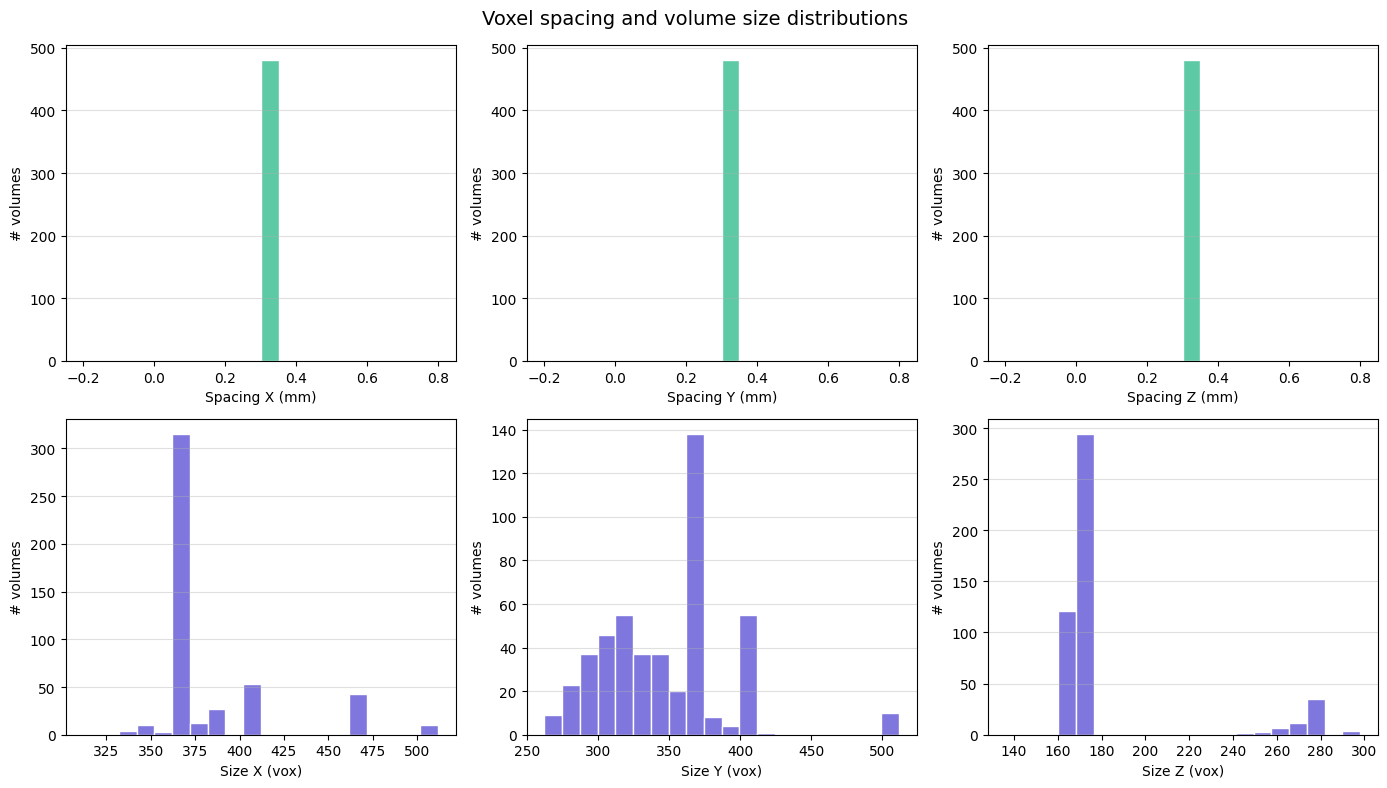

In [8]:
# spacing and volume size distributions
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Voxel spacing and volume size distributions", fontsize=14)

for ax, col, lbl in zip(axes[0], ["sp_x","sp_y","sp_z"],
                         ["Spacing X (mm)","Spacing Y (mm)","Spacing Z (mm)"]):
    ax.hist(df[col], bins=20, color="#5DCAA5", edgecolor="white")
    ax.set_xlabel(lbl); ax.set_ylabel("# volumes"); ax.grid(axis="y", alpha=0.4)

for ax, col, lbl in zip(axes[1], ["size_x","size_y","size_z"],
                         ["Size X (vox)","Size Y (vox)","Size Z (vox)"]):
    ax.hist(df[col], bins=20, color="#7F77DD", edgecolor="white")
    ax.set_xlabel(lbl); ax.set_ylabel("# volumes"); ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig(GRAPHS_DIR / "spacing_size_distributions.png", dpi=150)
plt.show()

100%|██████████| 10/10 [00:15<00:00,  1.60s/it]


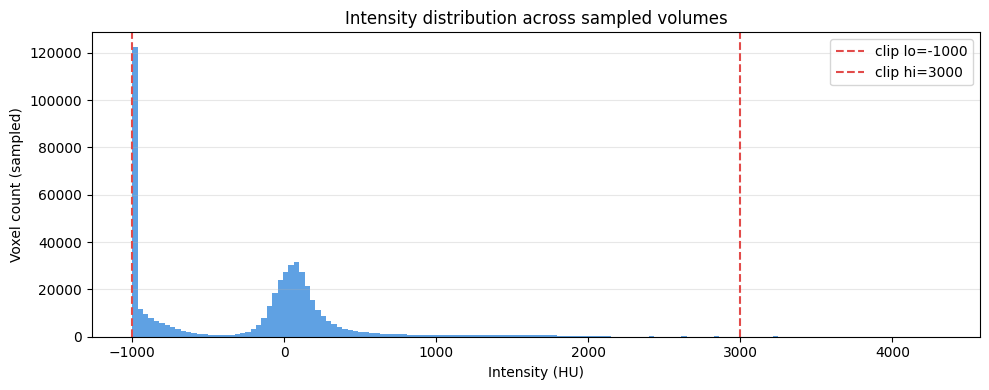

In [9]:
# intensity distribution
sample_ids = matched[:min(10, len(matched))]   # sample up to 10 for speed
all_vals   = []

for cid in tqdm(sample_ids):
    arr = sitk.GetArrayFromImage(sitk.ReadImage(str(img_ids[cid]))).ravel()
    # subsample 50k voxels per volume to keep memory sane
    idx = np.random.choice(len(arr), size=min(50_000, len(arr)), replace=False)
    all_vals.append(arr[idx])

flat = np.concatenate(all_vals)
clip_lo, clip_hi = cfg["data"]["intensity_clip"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(flat, bins=150, color="#378ADD", edgecolor="none", alpha=0.8)
ax.axvline(clip_lo, color="#E24B4A", lw=1.5, linestyle="--", label=f"clip lo={clip_lo}")
ax.axvline(clip_hi, color="#E24B4A", lw=1.5, linestyle="--", label=f"clip hi={clip_hi}")
ax.set_xlabel("Intensity (HU)"); ax.set_ylabel("Voxel count (sampled)")
ax.set_title("Intensity distribution across sampled volumes")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "intensity_distribution.png", dpi=150)
plt.show()

>The large spike at –1000 HU is air background - this dominates the voxel count. Soft tissue/bone signal clusters around 0–500 HU. The clip window [–1000, 3000] captures the full meaningful range; a few outlier maxima above 3000 exist but are negligible.

100%|██████████| 480/480 [00:41<00:00, 11.66it/s]


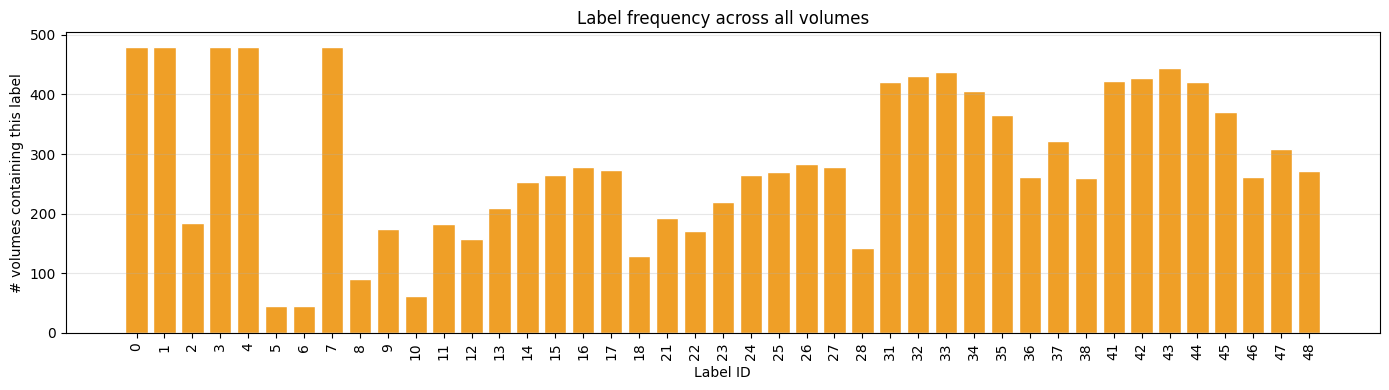

,label_id,n_volumes
0,0,480
1,1,479
2,2,185
3,3,480
4,4,480
5,5,46
6,6,45
7,7,480
8,8,90
9,9,174


In [10]:
# label frequency
from collections import Counter

label_counter = Counter()
for cid in tqdm(matched):
    lbl_arr = sitk.GetArrayFromImage(sitk.ReadImage(str(lbl_ids[cid])))
    for v in np.unique(lbl_arr):
        label_counter[int(v)] += 1

label_df = (pd.DataFrame.from_dict(label_counter, orient="index", columns=["n_volumes"])
              .reset_index().rename(columns={"index":"label_id"})
              .sort_values("label_id"))

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(label_df["label_id"].astype(str), label_df["n_volumes"],
       color="#EF9F27", edgecolor="white")
ax.set_xlabel("Label ID"); ax.set_ylabel("# volumes containing this label")
ax.set_title("Label frequency across all volumes")
ax.tick_params(axis="x", rotation=90)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "label_frequency.png", dpi=150)
plt.show()

label_df.to_csv(GRAPHS_DIR / "label_frequency.csv", index=False)
label_df

> Label IDs are not contiguous — they skip from 18→21, 28→31, etc. This is the FDI tooth numbering system (11–48), re-encoded. Labels 5, 6, 8 (IDs 5, 6, 8) appear in fewer than 100 volumes — these are rare/missing teeth and will need careful handling (weighted loss). Labels 31–34 and 41–44 dominate (~420–444 volumes each).

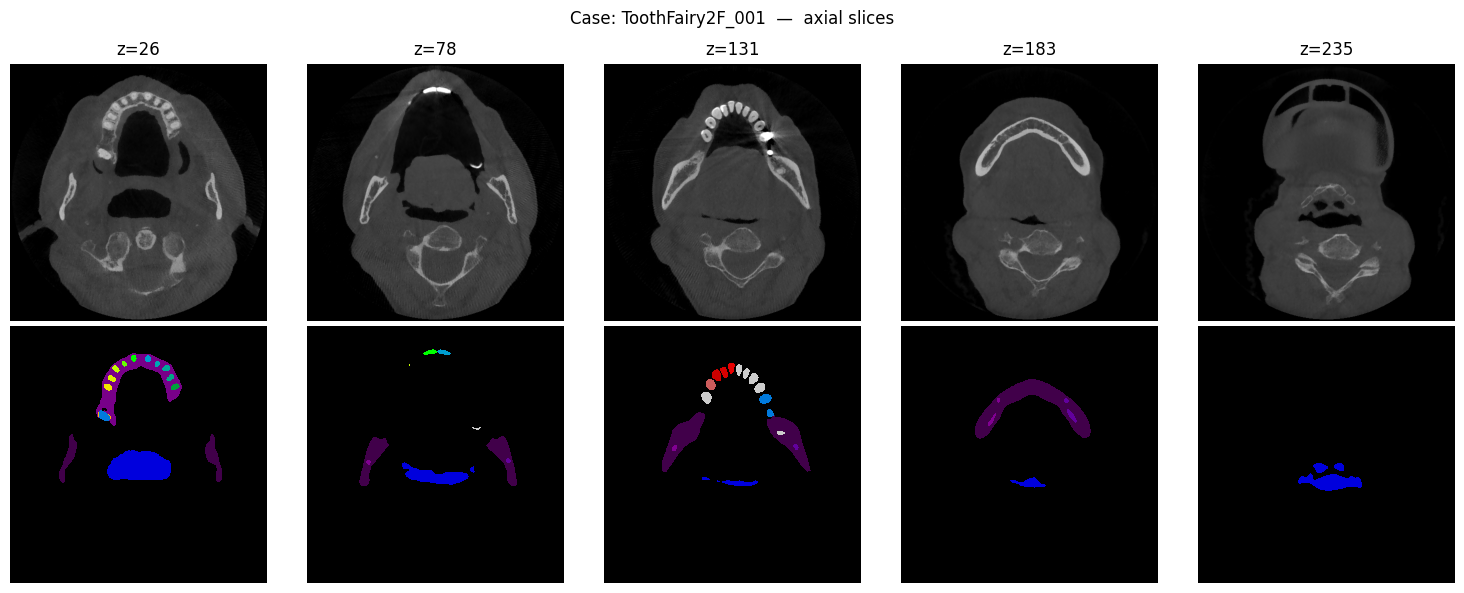

In [11]:
# visual inspeection
def show_volume_slices(case_id: str, n_slices: int = 5):
    img_arr = sitk.GetArrayFromImage(sitk.ReadImage(str(img_ids[case_id])))
    lbl_arr = sitk.GetArrayFromImage(sitk.ReadImage(str(lbl_ids[case_id])))

    z_total = img_arr.shape[0]
    indices = np.linspace(z_total * 0.1, z_total * 0.9, n_slices, dtype=int)

    fig, axes = plt.subplots(2, n_slices, figsize=(n_slices * 3, 6))
    fig.suptitle(f"Case: {case_id}  —  axial slices", fontsize=12)

    for col, zi in enumerate(indices):
        axes[0, col].imshow(img_arr[zi], cmap="gray",
                            vmin=cfg["data"]["intensity_clip"][0],
                            vmax=cfg["data"]["intensity_clip"][1])
        axes[0, col].set_title(f"z={zi}"); axes[0, col].axis("off")

        axes[1, col].imshow(lbl_arr[zi], cmap="nipy_spectral",
                            vmin=0, vmax=35, interpolation="none")
        axes[1, col].axis("off")

    axes[0, 0].set_ylabel("Image", fontsize=10)
    axes[1, 0].set_ylabel("Label", fontsize=10)
    plt.tight_layout()
    plt.savefig(GRAPHS_DIR / f"slices_{case_id}.png", dpi=130)
    plt.show()

show_volume_slices(matched[0])

> Slice viewer confirms: purple = upper/lower jaw bone, blue = mandible region, colored dots = individual teeth (FDI IDs). Teeth are very small relative to the full volume — strong class imbalance expected

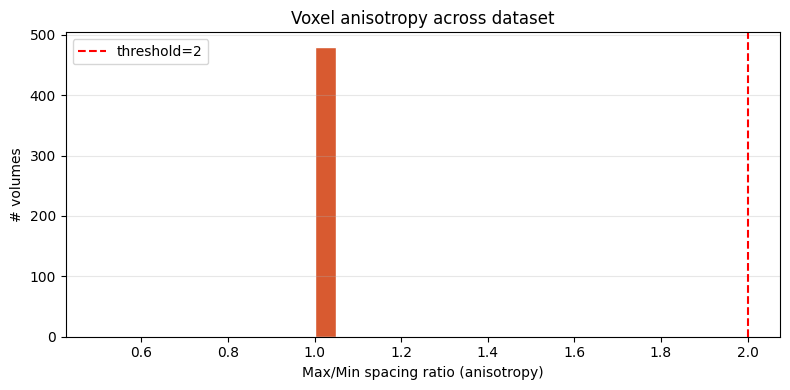

Highly anisotropic volumes (ratio > 2):
Empty DataFrame
Columns: [case_id, sp_x, sp_y, sp_z, anisotropy]
Index: []


In [12]:
# outlier check
df["anisotropy"] = df[["sp_x","sp_y","sp_z"]].max(axis=1) / df[["sp_x","sp_y","sp_z"]].min(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["anisotropy"], bins=20, color="#D85A30", edgecolor="white")
ax.set_xlabel("Max/Min spacing ratio (anisotropy)"); ax.set_ylabel("# volumes")
ax.set_title("Voxel anisotropy across dataset")
ax.axvline(2.0, color="red", lw=1.5, linestyle="--", label="threshold=2")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "anisotropy.png", dpi=150)
plt.show()

print("Highly anisotropic volumes (ratio > 2):")
print(df[df["anisotropy"] > 2][["case_id","sp_x","sp_y","sp_z","anisotropy"]])

>All 480 volumes have anisotropy ratio ≈ 1.0. The dataset is perfectly isotropic - no axis-specific augmentation bias needed

In [13]:
# summary
console.rule("[bold]EDA Summary")
rprint(f"Total matched pairs : [bold]{len(matched)}[/]")
rprint(f"Median spacing (mm) : x={df.sp_x.median():.3f}  y={df.sp_y.median():.3f}  z={df.sp_z.median():.3f}")
rprint(f"Median volume size : {df.size_x.median():.0f} × {df.size_y.median():.0f} × {df.size_z.median():.0f}")
rprint(f"Intensity range : [{df.img_min.min():.0f}, {df.img_max.max():.0f}]")
rprint(f"Unique label IDs : {sorted(label_counter.keys())}")
rprint(f"Highly anisotropic : {(df.anisotropy > 2).sum()} volumes")
rprint(f"\nAll graphs saved to : [cyan]{GRAPHS_DIR}[/]")

─────────────────────────────────────────────────── EDA Summary ───────────────────────────────────────────────────

Total matched pairs : 480

Median spacing (mm) : x=0.300  y=0.300  z=0.300

Median volume size : 371 × 347 × 169

Intensity range : [-1000, 5264]

Unique label IDs : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 21, 22, 23, 24, 25, 26, 27, 
28, 31, 32, 33, 34, 35, 36, 37, 38, 41, 42, 43, 44, 45, 46, 47, 48]

Highly anisotropic : 0 volumes

All graphs saved to : /home/saber/internships/assignments/cbct/results/graphs